# Exercise 5A: Steady-State Groundwater Model – Calibration

Elco Luijendijk | March 2026 | <elco.luijendijk@uib.no>

---

## Introduction

In this exercise you will build and calibrate a steady-state, depth-integrated
(one-layer) groundwater model for a real catchment in map view.  You will use
prepared geospatial datasets (elevation model, recharge, geology, surface water)
and apply calibration methods similar to Exercises 2 and 3, but extended to two
spatial dimensions.

**This notebook (5b) covers model setup and calibration.**  Flooding scenarios
and strategic pumping are in Exercise 5B, which loads the calibrated K field you
save at the end of this notebook.

## Objectives

- Set up a depth-integrated groundwater model from geospatial input datasets.
- Calibrate with multiple target types: observed water-table heads, seepage,
  and surface-water connectivity.
- Evaluate quality with RMSE, R², and a surface-water penalty for losing
  reaches (water table below rivers or lakes).
- Compare a uniform-transmissivity baseline with a geology-guided spatially
  variable model.

## What to hand in

- Your completed notebook with code, outputs, and written answers.
- Figures showing model setup, calibration quality, and spatial water-table
  distribution.

## Workflow

1. Load and visually inspect model input data.
2. Run a single-parameter (uniform T) baseline calibration.
3. Run a geology-guided multi-zone calibration.
4. Compare both calibrations using RMSE, R², and hydrological target metrics.
5. Save the best calibrated K field for use in Exercise 5B.

*Good luck, and ask for help if you get stuck.*

## Imports

In [34]:

# Run this cell once to install required packages, then comment it out again.
# On Google Colab all lines are needed.  On a local machine most packages
# are likely already installed; uncomment only what is missing.

# !pip install flopy                  # groundwater solver (MODFLOW 6 interface)
# !pip install rasterio               # GeoTIFF reading / rasterization
# !pip install xarray                 # NetCDF / array dataset (save results)
# !pip install cmcrameri              # perceptually-uniform scientific colormaps
# !pip install affine                 # affine transforms (rasterio dependency)


In [35]:

from pathlib import Path
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize_scalar, minimize
import xarray as xr
import cmcrameri.cm as cmc

import exercise_5_gw_model_utils as gwu
import exercise_5_gw_plot_utils as gwp

gwu = importlib.reload(gwu)
gwp = importlib.reload(gwp)

# Suppress repeated fallback warnings so the output stays readable.
warnings.filterwarnings('once',
    message='Using fallback solver because FLOPY/MF6 was unavailable*')
warnings.filterwarnings('once',
    message='Could not download mf6 executable*')

# ── Detect runtime environment ────────────────────────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

print(f"Running on {'Google Colab' if IN_COLAB else 'local machine'}")


Running on local machine


## Model Parameters

All key parameters are collected here.  Read through them before running the
rest of the notebook — understanding each one will help you answer the
assignment questions.

In [36]:

# Paths
if IN_COLAB:
    data_dir  = Path('/content/drive/MyDrive/GEOV212_model_input')
    model_dir = Path('/content/tmp_mf6_ex5')   # scratch space on the Colab VM
else:
    data_dir  = Path('data/model_input')
    model_dir = Path('tmp_mf6_ex5')
model_dir.mkdir(exist_ok=True)

# Grid resolution
target_cellsize_m = 100.0          # Target model cell size (m)

# Aquifer geometry
aquifer_thickness_m = 100.0        # Assumed uniform thickness; T = K * b (m)

# Sea boundary
sea_level_m = 0.0                  # Fixed head at open-sea cells (m a.s.l.)

# Drain parameters
# SW cells (rivers/lakes): fixed streambed/lake-bed clogging layer.
default_drain_bed_k_m_s       = 2e-6  # Streambed/lake-bed hydraulic conductivity (m/s)
default_drain_bed_thickness_m = 1.0   # Streambed/lake-bed thickness (m)
# Upland seepage-face cells: conductance scales with local aquifer K.
# C = K[r,c] * dx * dy / drain_coupling_depth_m  (Rushton 2003; Beven 1981)
drain_coupling_depth_m        = 1.0   # Effective coupling depth for upland drain cells (m)

# Slope correction for steep terrain (True = physically more correct)
# In plan-view 2D models, steep terrain means longer flow paths between cells.
# The correction reduces T by 1/(1+slope^2) so high-relief areas have lower
# effective horizontal transmissivity.
apply_slope_correction = True

# Calibration loss weights.
# Increasing a weight makes calibration pay more attention to that criterion.
cal_weights = {
    'w_rmse'    : 1.0,   # Head RMSE at observation borehole points
    'w_r2'      : 0.75,  # R² at observation points
    'w_seepage' : 0.5,   # Seepage-match fraction at surface-water cells
    'w_sw_stage': 0.3,   # Surface-water stage RMSE
    'w_below_wt': 0.5,   # Fraction of SW cells where WT < river/lake bed
}

# Default figure size (width <= 10 inches to keep font sizes legible).
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

print(f'Data directory : {data_dir.resolve()}')
print(f'Model directory: {model_dir.resolve()}')


Data directory : /Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/data/model_input
Model directory: /Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/tmp_mf6_ex5


In [37]:

# ── Map helper wrappers ────────────────────────────────────────────────────────
# The actual code lives in exercise_5_gw_plot_utils.py.
# These thin wrappers supply the global `grid` dict automatically so that
# existing call sites (e.g. in the input-data figure below) stay unchanged.

def _cbar(im, ax, label='', **kw):
    """Add a colorbar matched to the axes height."""
    return gwp._cbar(im, ax, label, **kw)

def _panel_h():
    """Map panel height (inches) for the current grid aspect ratio."""
    return gwp._panel_h(nrow, ncol)

def add_map_ticks(ax, **kw):
    """Add easting/northing tick labels to a map axes."""
    return gwp.add_map_ticks(ax, grid, **kw)

def add_map_overlays(ax, **kw):
    """Overlay domain boundary and sea mask."""
    return gwp.add_map_overlays(ax, grid, **kw)

print('Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).')


Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).



---
## Part A: Load and Inspect the Model Input Data

`gwu.load_and_coarsen_inputs` reads five GeoTIFF rasters from `data/model_input/`,
coarsens them to the target cell size, and returns a dictionary of arrays.

**Boundary-condition scheme:**

| Cell type | Boundary |
|---|---|
| Sea cells (`sea == 1`) | Constant head = `sea_level_m` (fixed open-water level, 0 m a.s.l.) |
| River/lake cells (non-sea) | Seepage/drain face with 5× enhanced conductance; drain elevation = DEM − 0.15 m |
| All other active cells | Seepage/drain face; drain elevation = DEM − 1.0 m |
| Lowest SW cell (only when no sea present) | Constant head = land-surface elevation (hydraulic anchor) |

Drains activate **only** when the modelled head exceeds the drain elevation, so
cells with a deep water table stay dry at the surface.

**Why inspect first?**  A quick visual check can reveal unit errors, misaligned
rasters, or missing values before they cause confusing calibration results.


**Expected output:**
- Grid loads without errors.
- Non-zero counts for active, sea, and surface-water cells.
- Recharge in a plausible range (50–600 mm/yr for a Norwegian catchment).

In [38]:

grid_data = gwu.load_and_coarsen_inputs(data_dir, target_cellsize_m)

dem       = grid_data['dem']
sw        = grid_data['sw']
sea       = grid_data['sea']
geo       = grid_data['geo']
rch       = grid_data['rch']
active    = grid_data['active']
transform = grid_data['transform']
delr      = grid_data['delr']
delc      = grid_data['delc']
nrow      = grid_data['nrow']
ncol      = grid_data['ncol']
factor    = grid_data['factor']
native_dx = grid_data['native_dx']

is_sea   = (sea == 1) & active
sw_cells = (sw > 0) & (sw < 3) & active & ~is_sea
rch_mm_yr = rch * 365.25 * 24 * 3600 * 1000  # m/s → mm/yr for display

print(f'Coarsening factor: {factor}  (native ~{native_dx:.1f} m → model ~{delr:.1f} m)')
print(f'Grid: {nrow} rows × {ncol} cols')
print(f'Active cells:          {active.sum():,}')
print(f'Sea cells (CHD):       {is_sea.sum():,}')
print(f'SW cells (lake+river): {sw_cells.sum():,}')
rch_active = rch_mm_yr[active]
print(f'Recharge range (active): {rch_active.min():.0f} – {rch_active.max():.0f} mm/yr')
if rch_active.min() == rch_active.max():
    print('  Note: recharge is spatially uniform.')

# ── Grid info dict – passed to all plotting functions ──────────────────────────
grid = dict(
    dem=dem, active=active, sw_cells=sw_cells, is_sea=is_sea,
    nrow=nrow, ncol=ncol, delr=delr, delc=delc,
    transform=transform, aquifer_thickness_m=aquifer_thickness_m,
)


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:37: RuntimeWarning: Mean of empty slice
  return np.nanmean(view, axis=(1, 3))


Coarsening factor: 10  (native ~10.0 m → model ~100.0 m)
Grid: 105 rows × 138 cols
Active cells:          7,954
Sea cells (CHD):       3,158
SW cells (lake+river): 168
Recharge range (active): nan – nan mm/yr


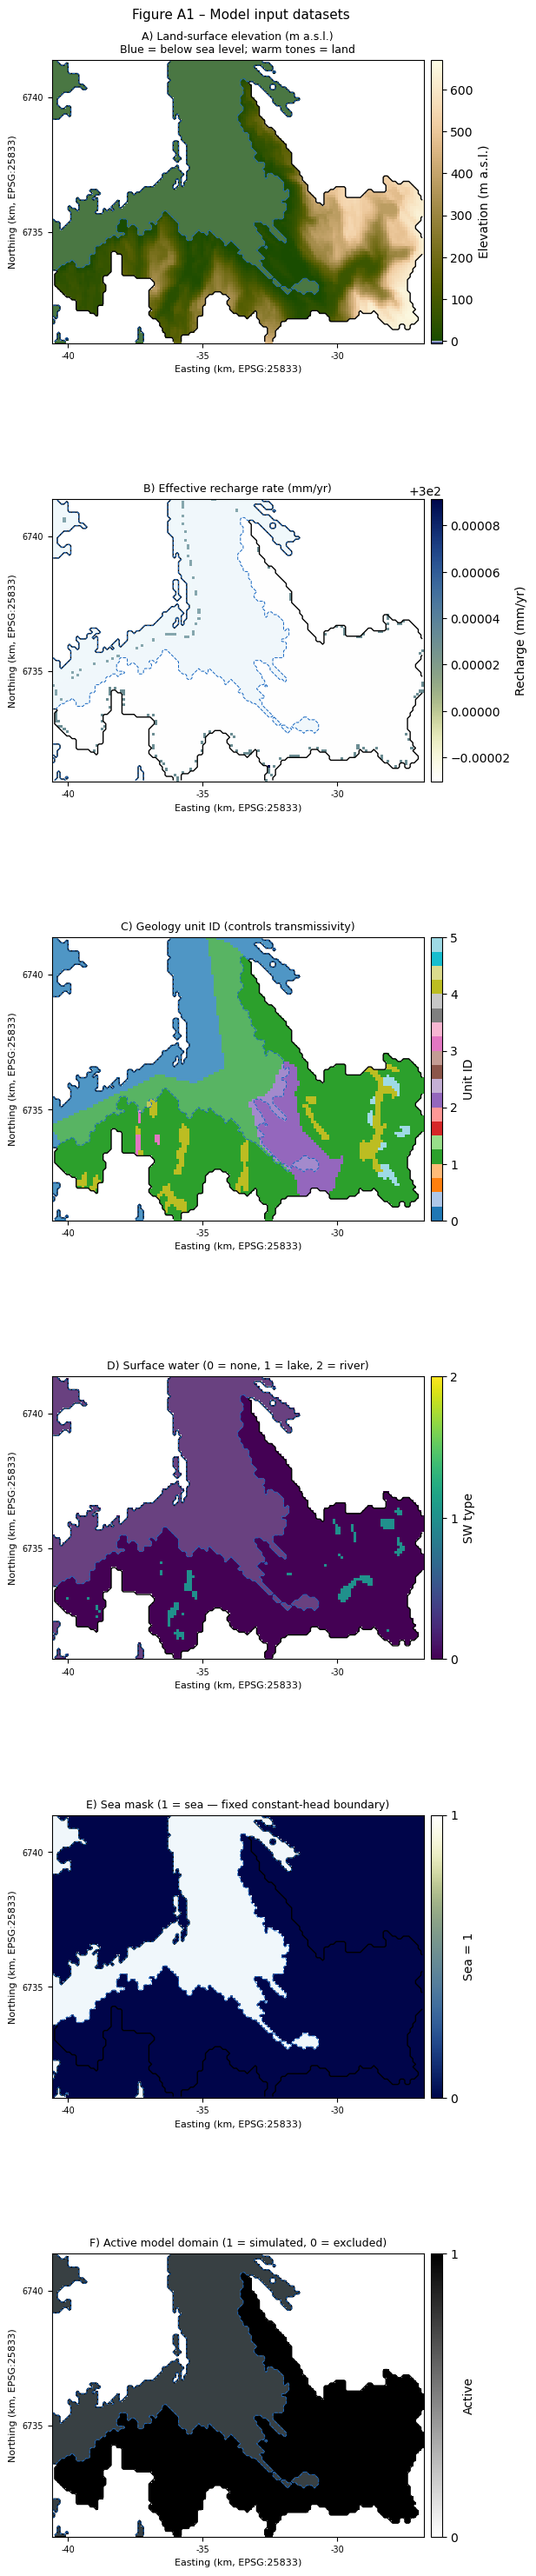

In [39]:

# Figure A1: Input data overview (6 panels, single column for full-width maps)
ph = _panel_h()
fig, axes = plt.subplots(6, 1, figsize=(7, 6 * ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.97, bottom=0.01, hspace=0.55)

# Elevation: anchor colormap at 0 m so ocean colours appear only below sea level.
# cmc.oleron is designed exactly for this (blue below 0, land colours above).
from matplotlib.colors import TwoSlopeNorm
_dem_min = float(np.nanmin(dem[active]))
_dem_max = float(np.nanmax(dem[active]))
_elev_norm = TwoSlopeNorm(vmin=min(_dem_min, -5.0), vcenter=0.0, vmax=_dem_max)
im0 = axes[0].imshow(np.where(active, dem, np.nan), cmap=cmc.oleron, norm=_elev_norm)
axes[0].set_title('A) Land-surface elevation (m a.s.l.)\n'
                  'Blue = below sea level; warm tones = land', fontsize=9)
_cbar(im0, axes[0], 'Elevation (m a.s.l.)')

im1 = axes[1].imshow(np.where(active, rch_mm_yr, np.nan), cmap=cmc.davos_r)
axes[1].set_title('B) Effective recharge rate (mm/yr)', fontsize=9)
_cbar(im1, axes[1], 'Recharge (mm/yr)')

im2 = axes[2].imshow(np.where(active, geo, np.nan), cmap='tab20')
axes[2].set_title('C) Geology unit ID (controls transmissivity)', fontsize=9)
_cbar(im2, axes[2], 'Unit ID')

sw_display = np.where(sw_cells, sw.astype(float), 0.0)
im3 = axes[3].imshow(np.where(active, sw_display, np.nan),
                     cmap='viridis', vmin=0, vmax=2)
axes[3].set_title('D) Surface water (0 = none, 1 = lake, 2 = river)', fontsize=9)
_cbar(im3, axes[3], 'SW type', ticks=[0, 1, 2])

im4 = axes[4].imshow(sea.astype(float), cmap=cmc.davos, vmin=0, vmax=1)
axes[4].set_title('E) Sea mask (1 = sea — fixed constant-head boundary)', fontsize=9)
_cbar(im4, axes[4], 'Sea = 1', ticks=[0, 1])

im5 = axes[5].imshow(active, cmap='gray_r', vmin=0, vmax=1)
axes[5].set_title('F) Active model domain (1 = simulated, 0 = excluded)', fontsize=9)
_cbar(im5, axes[5], 'Active', ticks=[0, 1])

for ax in axes:
    add_map_ticks(ax)
    add_map_overlays(ax)

fig.suptitle('Figure A1 – Model input datasets', fontsize=11, y=0.99)
plt.show()



---
## Part B: Model Helper Functions

The solver and metric code lives in `exercise_5_gw_model_utils.py`.  Here we
define two thin wrappers:

- `run_model` – runs one simulation and returns head + diagnostics.
- `evaluate_candidate` – runs the model, computes all metrics, returns a dict.

**Slope correction for steep terrain** (controlled by `apply_slope_correction`):
A plan-view 2D model assumes a flat aquifer.  In steep terrain the actual flow
path between cells is longer than the cell spacing, so the effective horizontal
transmissivity is reduced:

$$T_\text{eff} = \frac{T}{1 + s^2}, \quad s = \|\nabla z\| \text{ (m/m)}$$

The correction factor $1/(1+s^2)$ is pre-computed from the DEM once and applied
inside `run_model`.  Upland cells with slopes > 5 m/m are clipped to 5 m/m.

**Boundary conditions applied:**
- Sea cells → constant head (0 m a.s.l.).
- All other active cells → seepage face / drain (activates when head > drain elevation).
- When no sea is present, the lowest surface-water cell is the hydraulic anchor (CHD).


In [40]:

# Pre-compute the slope correction factor from the DEM (done once, reused every run).
_, slope_factor = gwu.apply_slope_correction(
    np.ones_like(dem), dem, delr, delc, active
)
print(f'Slope correction factor – mean: {slope_factor[active].mean():.3f}, '
      f'min: {slope_factor[active].min():.3f}')


def run_model(hk_arr, recharge_multiplier=1.0, wells=None):
    """Run one steady-state simulation with a given K field.

    Parameters
    ----------
    hk_arr : ndarray
        2-D hydraulic conductivity (m/s), same shape as dem.
        The global `apply_slope_correction` flag controls whether
        K is reduced in steep-slope cells before the model run.
    recharge_multiplier : float
        Scale all recharge values.  > 1 = wetter.  Default 1.0.
    wells : list of dict, optional
        Pumping wells; see gwu.simulate for format.  Default None.

    Returns
    -------
    head : ndarray  – hydraulic head (m a.s.l.), NaN outside active domain.
    diagnostics : dict
    """
    if apply_slope_correction:
        hk_use, _ = gwu.apply_slope_correction(hk_arr, dem, delr, delc, active)
    else:
        hk_use = hk_arr

    return gwu.simulate(
        hk_arr=hk_use,
        dem=dem, sw=sw, sea=sea, active=active, rch=rch,
        nrow=nrow, ncol=ncol, delr=delr, delc=delc,
        model_dir=model_dir,
        aquifer_thickness_m=aquifer_thickness_m,
        recharge_multiplier=recharge_multiplier,
        sea_level_m=sea_level_m,
        k_bed=default_drain_bed_k_m_s,
        b_bed=default_drain_bed_thickness_m,
        b_eff=drain_coupling_depth_m,
        wells=wells,
    )


def evaluate_candidate(hk_arr, obs_grid_df):
    """Run the model and compute all calibration metrics for a K field.

    Parameters
    ----------
    hk_arr : ndarray – 2-D hydraulic conductivity (m/s).
    obs_grid_df : pd.DataFrame – observations mapped to grid.

    Returns
    -------
    dict with keys 'head', 'diagnostics', 'eval_df', 'obs_stats',
    'target_stats', 'loss'.
    """
    head, diagnostics = run_model(hk_arr)
    eval_df, obs_stats = gwu.evaluate_vs_obs(head, obs_grid_df)
    target_stats = gwu.seepage_surfacewater_targets(
        head, diagnostics, sw, active)

    loss = gwu.combined_calibration_loss(
        obs_stats, target_stats,
        w_rmse    =cal_weights['w_rmse'],
        w_r2      =cal_weights['w_r2'],
        w_seepage =cal_weights['w_seepage'],
        w_sw_stage=cal_weights['w_sw_stage'],
        w_below_wt=cal_weights['w_below_wt'],
    )
    return {
        'head': head, 'diagnostics': diagnostics,
        'eval_df': eval_df, 'obs_stats': obs_stats,
        'target_stats': target_stats, 'loss': float(loss),
    }


Slope correction factor – mean: 0.925, min: 0.044


In [41]:

# ── Plotting wrappers ──────────────────────────────────────────────────────────
# The plotting functions are defined in exercise_5_gw_plot_utils.py.
# These thin wrappers capture the notebook's global `grid` dict so callers
# do not need to pass it explicitly.

def plot_model_output(head, diagnostics, hk_arr, label, show_obs=None):
    """5-panel map: water table, depth-to-WT, Darcy flux, seepage, T."""
    gwp.plot_model_output(head, diagnostics, hk_arr, label, grid,
                          show_obs=show_obs)


def plot_calibration_comparison(head, diagnostics, eval_df,
                                 obs_stats, targets, label):
    """3-panel calibration quality: map (obs coloured by depth), scatter, gaining/losing."""
    gwp.plot_calibration_comparison(head, diagnostics, eval_df,
                                    obs_stats, targets, label, grid)


def plot_cross_sections(head, diagnostics, label, transects=None):
    """
    Plot 2-D hydrogeological cross-sections.

    If *transects* is None, sections are placed automatically perpendicular to
    the water-table contours.  Pass *user_transects* (built in the cell below)
    to use student-defined start/end coordinates instead.
    """
    if transects is None:
        transects = gwu.find_cross_section_transects(
            head, active, nrow, ncol, delr, delc, n_sections=3)
    gwp.plot_cross_sections(
        transects, head, dem, sw, diagnostics['drn_flux'],
        active, delr, delc, aquifer_thickness_m, label)


print('plot_model_output(), plot_calibration_comparison(), '
      'plot_cross_sections() ready.')


plot_model_output(), plot_calibration_comparison(), plot_cross_sections() ready.


---
## Part C: Baseline Calibration – Uniform Transmissivity

We calibrate a single effective transmissivity T = K × b applied uniformly to
all active cells.

`scipy.optimize.minimize_scalar` searches for the log₁₀(T) that minimises the
combined calibration loss.  The loss balances:

- **RMSE and R²** at borehole / well water-table observations.
- **Seepage match**: are mapped rivers/lakes receiving groundwater discharge?
- **Surface-water stage RMSE**: how well does modelled head match drain
  elevation at SW cells?
- **Losing-reach penalty**: fraction of SW cells where the water table lies
  *below* the riverbed (indicating the model may underpredict transmissivity).

**Expected output:**
- Calibrated T in m²/s is printed.
- RMSE, R², and surface-water target metrics are printed.
- Figure C1: modelled water-table elevation (m a.s.l.) with scatter.
- Figure C2: head residuals and a losing-reach map.

In [42]:

import json as _json

# ── GRANADA static well observations (NGU borehole database) ─────────────────
# wells_static.geojson records depth-to-water measured at the time of
# well construction or afterward.  All wells with a valid water-level reading
# are used, including deep bedrock wells, because in Norwegian terrain the
# bedrock water table can be tens of metres below the surface and is a
# meaningful constraint even for the shallow aquifer model.
#
# Filtering rules applied:
#   1. depth_to_water_m must be present (not null).
#   2. depth_to_water_m < drilled_depth_m  →  excludes borehole-bottom artefacts.
#   3. depth_to_water_m > 0  →  excludes wells with WT exactly at the collar
#      (often unreliable or artesian artefacts in the GRANADA database).

_ws_path = data_dir / 'wells_static.geojson'
with open(_ws_path) as _f:
    _ws_gj = _json.load(_f)

_ws_rows = []
for _feat in _ws_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _dtw     = _p.get('depth_to_water_m')
    _drilled = _p.get('drilled_depth_m') or 9999.0
    _geol    = _p.get('geol_medium', '')

    if _dtw is None or pd.isna(_dtw):
        continue                                    # no measurement
    if float(_dtw) >= float(_drilled):
        continue                                    # artefact: depth = bottom of bore
    if float(_dtw) <= 0.0:
        continue                                    # zero/negative DTW: artesian or artefact

    _ws_rows.append({
        'station_id':       str(_p['well_id']),
        'source':           'GRANADA_static',
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': np.nan,
        'depth_to_water_m': float(_dtw),
    })

wells_static_obs = pd.DataFrame(_ws_rows)
print(f'GRANADA static wells passing filters: {len(wells_static_obs)} '
      f'(out of {len(_ws_gj["features"])} total)')

# ── Load NVE monitoring-station observations from wells_timeseries.geojson ───
# wells_timeseries.geojson is produced by exercise_5a and contains NVE
# groundwater monitoring stations with point geometry (EPSG:25833) and
# water_level_masl / depth_to_water_m observations.
# Multiple time-steps per station are averaged to a single representative head.

_wt_path = data_dir / 'wells_timeseries.geojson'
with open(_wt_path) as _f:
    _wt_gj = _json.load(_f)

_wt_rows = []
for _feat in _wt_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _wl     = _p.get('water_level_masl')
    _dtw    = _p.get('depth_to_water_m')

    # Skip rows with no usable water-level information
    if (_wl is None or pd.isna(_wl)) and (_dtw is None or pd.isna(_dtw)):
        continue

    _wt_rows.append({
        'station_id':       str(_p['station_id']),
        'source':           str(_p.get('source', 'NVE_timeseries')),
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': float(_wl)  if (_wl  is not None and not pd.isna(_wl))  else np.nan,
        'depth_to_water_m': float(_dtw) if (_dtw is not None and not pd.isna(_dtw)) else np.nan,
    })

# Deduplicate: multiple time-steps per station → mean water level
_wt_df = pd.DataFrame(_wt_rows)
if not _wt_df.empty:
    _wt_df = (
        _wt_df
        .groupby('station_id', as_index=False)
        .agg({'source': 'first', 'x': 'first', 'y': 'first',
              'water_level_masl': 'mean', 'depth_to_water_m': 'mean'})
    )
obs = _wt_df
print(f'NVE timeseries stations with water-level data: {len(obs)}')

obs_combined = pd.concat([obs, wells_static_obs], ignore_index=True)

obs_grid = gwu.map_obs_to_grid(obs_combined, transform, active, dem)
print(f'Total rows mapped to active cells (all sources, raw): {len(obs_grid)}')
print(f'  NVE source rows: {(obs_grid["source"] != "GRANADA_static").sum()}')
print(f'  GRANADA static rows: {(obs_grid["source"] == "GRANADA_static").sum()}')

# ── Deduplicate: multiple rows at the same cell → keep mean head ──────────────
obs_grid = (obs_grid
            .groupby(['r', 'c'], as_index=False)
            .agg({'obs_head_m': 'mean', 'station_id': 'first', 'source': 'first'}))
obs_grid = obs_grid.reset_index(drop=True)
obs_grid.insert(0, 'well_no', range(1, len(obs_grid) + 1))

# Add DEM elevation and depth-to-WT at each observation cell.
obs_grid['dem_m']       = [dem[r, c] for r, c in zip(obs_grid['r'], obs_grid['c'])]
obs_grid['obs_depth_m'] = obs_grid['dem_m'] - obs_grid['obs_head_m']
# Sanity check: drop observations where the observed head is above the land surface.
_n_pre_filter = len(obs_grid)
obs_grid = obs_grid[obs_grid['obs_depth_m'] >= 0.0].copy()
obs_grid['well_no'] = range(1, len(obs_grid) + 1)
_n_dropped = _n_pre_filter - len(obs_grid)
if _n_dropped:
    print(f'Note: {_n_dropped} observation(s) dropped — observed head above DEM '
          f'(DEM resolution mismatch or artesian conditions).')

print('\nObservation well inventory (obs_head_m = water-level m a.s.l.):')
display(obs_grid[['well_no', 'station_id', 'source',
                   'dem_m', 'obs_head_m', 'obs_depth_m']].round(1).to_string(index=False))

# ── Calibrate uniform transmissivity ─────────────────────────────────────────
cache_uniform = {}


def objective_uniform(log10_t):
    """Return calibration loss for uniform T = 10**log10_t (m2/s)."""
    key = round(float(log10_t), 3)
    if key not in cache_uniform:
        t_val = 10.0 ** log10_t
        hk = np.where(active, t_val / aquifer_thickness_m, 1e-12)
        cache_uniform[key] = evaluate_candidate(hk, obs_grid)['loss']
    return cache_uniform[key]



# ── Pre-calibration forward run (default T = 1e-4 m²/s) ──────────────────────────────
# Run the model once before optimisation so students can compare the
# initial (uncalibrated) result against the calibrated output.
_T_init = 1e-4   # m²/s – a geologically typical transmissivity
_hk_init = np.where(active, _T_init / aquifer_thickness_m, 1e-12)
_init_result = evaluate_candidate(_hk_init, obs_grid)
print(f'Pre-calibration run  T = {_T_init:.1e} m²/s  '
      f'(K = {_T_init/aquifer_thickness_m:.1e} m/s)')
print(f"  RMSE = {_init_result['obs_stats']['rmse']:.2f} m")
print(f"  R²   = {_init_result['obs_stats']['r2']:.3f}")
print(f"  Loss = {_init_result['loss']:.3f}")

res_u = minimize_scalar(
    objective_uniform,
    bounds=(-7.0, -2.0), method='bounded',
    options={'xatol': 0.05, 'maxiter': 25},
)

best_t_uniform  = 10.0 ** res_u.x
best_hk_uniform = np.where(active, best_t_uniform / aquifer_thickness_m, 1e-12)
uniform_result  = evaluate_candidate(best_hk_uniform, obs_grid)

head_uniform    = uniform_result['head']
diag_uniform    = uniform_result['diagnostics']
eval_uniform    = uniform_result['eval_df']
stats_uniform   = uniform_result['obs_stats']
targets_uniform = uniform_result['target_stats']

print(f"Solver: {diag_uniform['engine']}   anchor: {diag_uniform['anchor']}")
print(f'Best T = {best_t_uniform:.3e} m²/s  (K = {best_t_uniform/aquifer_thickness_m:.3e} m/s)')
print()
print('Observation statistics:')
for k, v in stats_uniform.items():
    print(f'  {k:<20s}: {v}')

print()
print('Surface-water / seepage targets:')
for k, v in targets_uniform.items():
    print(f'  {k:<40s}: {v}')

print(f"\nCombined calibration loss: {uniform_result['loss']:.3f}")

activation_uniform = gwu.check_drain_activation(
    head_uniform, diag_uniform, sw, sea, active)
print('\nDrain activation summary:')
display(activation_uniform)


GRANADA static wells passing filters: 16 (out of 64 total)
NVE timeseries stations with water-level data: 16
Total rows mapped to active cells (all sources, raw): 32
  NVE source rows: 16
  GRANADA static rows: 16
Note: 2 observation(s) dropped — observed head above DEM (DEM resolution mismatch or artesian conditions).

Observation well inventory (obs_head_m = water-level m a.s.l.):


' well_no station_id         source     dem_m  obs_head_m  obs_depth_m\n       1      21330 GRANADA_static 18.600000        17.1          1.5\n       2      55886 GRANADA_static 31.700001        24.7          7.0\n       3     119296 GRANADA_static  3.500000         2.5          1.0\n       4      10004 GRANADA_static 39.000000       -31.0         70.0\n       5     141713 GRANADA_static 48.099998        47.5          0.6\n       6     141715 GRANADA_static 63.099998        61.6          1.5\n       7     141714 GRANADA_static 57.599998        54.6          3.0\n       8     141718 GRANADA_static 43.299999        39.5          3.8\n       9     141717 GRANADA_static 52.099998        51.6          0.5\n      10     129754 GRANADA_static  2.000000         0.0          2.0\n      11     129758 GRANADA_static  1.800000        -0.4          2.2\n      12     129762 GRANADA_static  2.900000         1.2          1.7\n      13     129763 GRANADA_static  2.400000         1.1          1.3'

/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


Pre-calibration run  T = 1.0e-04 m²/s  (K = 1.0e-06 m/s)
  RMSE = 15.44 m
  R²   = 0.675
  Loss = 4.270


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")
/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")
/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")
/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY n

Solver: iterative-fallback   anchor: sea cells as fixed head (0 m)
Best T = 7.541e-05 m²/s  (K = 7.541e-07 m/s)

Observation statistics:
  n                   : 13
  rmse                : 14.992016202338664
  mae                 : 7.824895222691127
  bias                : 0.2966428773245837
  r2                  : 0.6932202652290287

Surface-water / seepage targets:
  n_surface_water_cells                   : 168
  seepage_match_fraction                  : 0.05357142857142857
  surfacewater_stage_rmse_m               : 50.798752953064565
  seepage_surfacewater_jaccard            : 0.027190332326283987
  n_sw_below_wt                           : 159
  below_wt_fraction                       : 0.9464285714285714

Combined calibration loss: 4.176

Drain activation summary:


,feature,n_cells,n_drn_active,active_fraction
0,river,0,0,NaN
1,lake,168,9,0.053571
2,sea,3158,0,1.000000


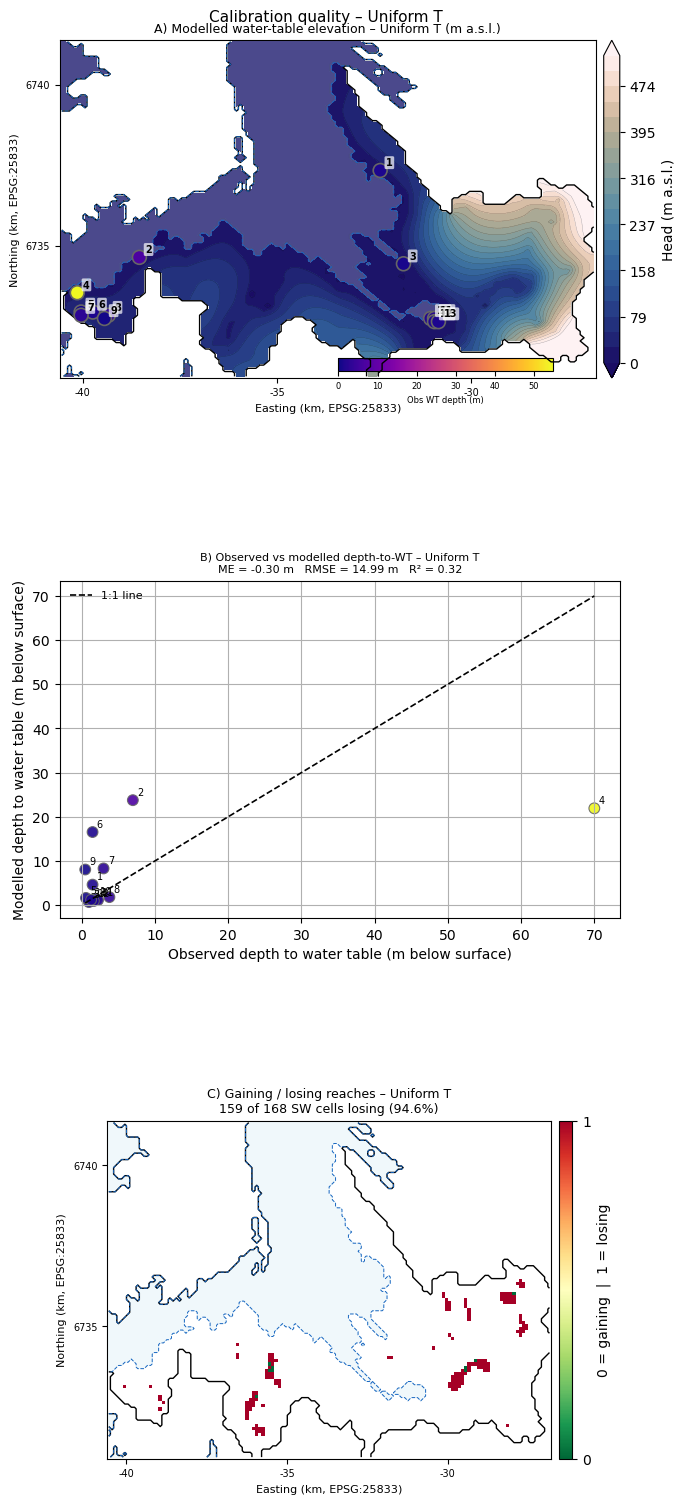


Modelled vs observed depth-to-water-table – Uniform T:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,21330,1.50,4.65,3.15
1,2,55886,7.00,23.77,16.77
2,3,119296,1.00,0.70,-0.30
4,4,10004,70.00,21.93,-48.07
6,5,141713,0.60,1.65,1.05
7,6,141715,1.50,16.56,15.06
8,7,141714,3.00,8.32,5.32
9,8,141718,3.80,1.83,-1.97
10,9,141717,0.50,8.08,7.58
11,10,129754,2.00,1.43,-0.57


In [43]:

# Calibration quality: map, scatter, residuals, gaining/losing reaches
plot_calibration_comparison(
    head_uniform, diag_uniform, eval_uniform,
    stats_uniform, targets_uniform, 'Uniform T'
)

# Modelled vs observed depth-to-WT table (numbered wells)
if not eval_uniform.empty:
    print('\nModelled vs observed depth-to-water-table – Uniform T:')
    tbl = eval_uniform.copy()
    tbl['model_depth_m'] = tbl['dem_m'] - tbl['model_head_m']
    tbl['depth_resid_m'] = tbl['model_depth_m'] - tbl['obs_depth_m']
    tbl_disp = tbl[['well_no', 'station_id',
                     'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_disp.columns = ['Well #', 'Station ID',
                         'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_disp)


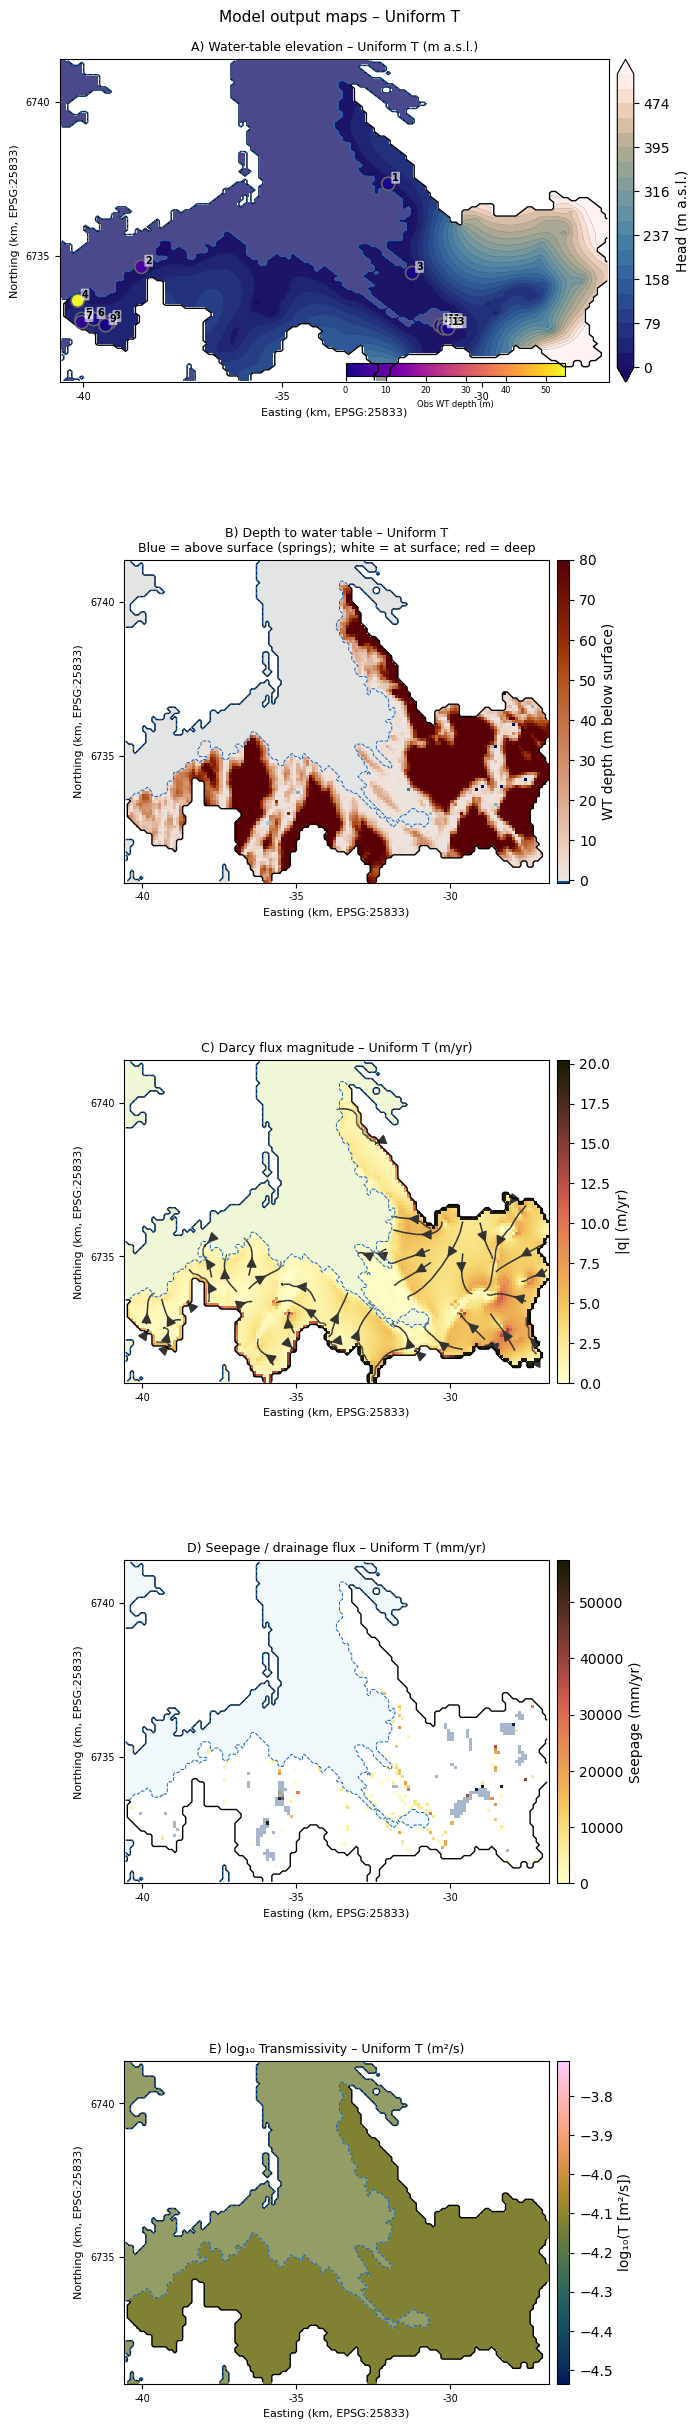

In [44]:

# Full model output maps for the uniform-T calibration
plot_model_output(
    head_uniform, diag_uniform, best_hk_uniform, 'Uniform T',
    show_obs=eval_uniform if not eval_uniform.empty else None
)
# Also keep the losing-reach diagnostic arrays for Part D comparison
drn_elev_u = diag_uniform['drn_elev']
below_wt_u = sw_cells & np.isfinite(head_uniform) & (head_uniform < drn_elev_u)


In [45]:

# ── Student-defined cross-section lines ────────────────────────────────────────
# Enter start and end coordinates (easting, northing in metres, EPSG:25833) for
# each cross-section you want to plot.
#
# How to pick good coordinates:
#   • Read easting and northing (in metres) off the map tick labels above.
#     Tick labels show kilometres; multiply by 1000 to get metres.
#   • Orient sections along the flow direction (high head → low head) to
#     show the saturated zone and discharge zone clearly.
#   • A coast-perpendicular section captures sea–land WT gradients.
#   • A section along a valley floor shows shallow WT and seepage zones.
#
# Run this cell with the placeholder values first to check the layout,
# then refine the coordinates based on the cross-section overview map.

user_xsection_endpoints = [
    {'label': 'Section 1 (W–E)',
     'start_xy': (-37000, 6735000),
     'end_xy':   (-33000, 6735000)},
    {'label': 'Section 2 (N–S)',
     'start_xy': (-35500, 6738000),
     'end_xy':   (-35500, 6733000)},
    # Add or remove entries as needed:
    # {'label': 'Section 3', 'start_xy': (x0, y0), 'end_xy': (x1, y1)},
]

# Build transect dicts from the endpoint coordinates.
user_transects = []
for ep in user_xsection_endpoints:
    try:
        tr = gwu.make_transect_from_endpoints(
            ep['start_xy'], ep['end_xy'],
            transform, delr, delc, active, label=ep['label'])
        user_transects.append(tr)
        km = tr['dist_m'][-1] / 1000.0
        print(f"  {tr['label']}: {len(tr['rows'])} active cells, "
              f"length {km:.1f} km")
    except ValueError as exc:
        print(f'  Warning [{ep["label"]}]: {exc}')

if not user_transects:
    print('No valid transects — check coordinates above.')
    print('Automatic section placement will be used as fallback.')


  Section 1 (W–E): 41 active cells, length 4.0 km
  Section 2 (N–S): 49 active cells, length 5.0 km


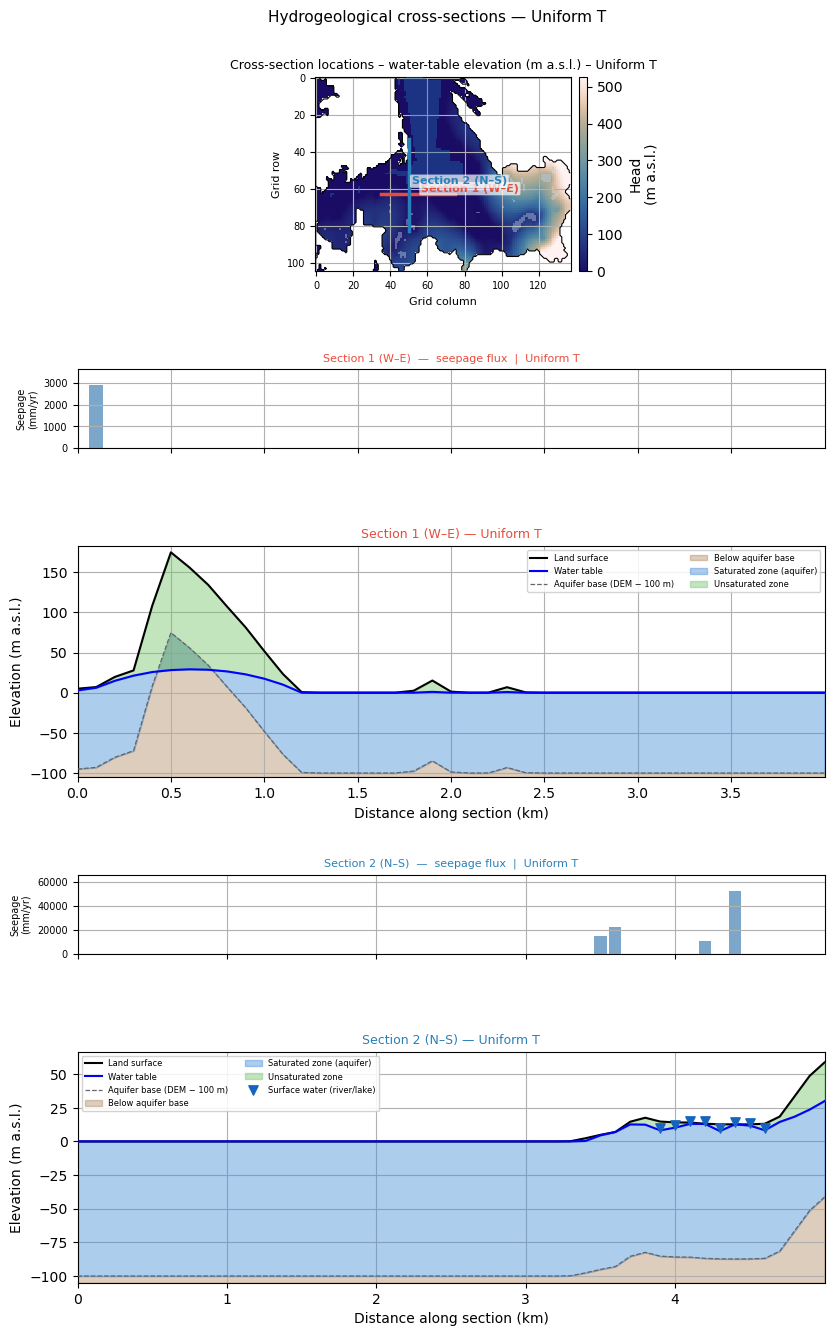

In [46]:

# Cross-sections along student-defined lines – Uniform T
plot_cross_sections(head_uniform, diag_uniform, 'Uniform T',
                    transects=user_transects if user_transects else None)


---
## Part D: Geology-Based Calibration with Spatially Variable K

Hydraulic conductivity varies by several orders of magnitude between
sediment and rock types, so a uniform T is physically unrealistic.

This part has three stages:

### Stage D1 (Optional — geology unit K assignment)
A table of all geology units present in the active model domain is printed.
Inspect the `deposit_type` and `gw_potential` columns, then optionally assign
your own K value to any unit.  If you leave `custom_k_by_unit = {}` empty the
code uses K values inferred automatically from Norwegian keywords in the legend.

### Stage D2 — Define calibration groups
Instead of calibrating each geology unit individually (too many parameters),
you group the units into **two or more geological categories** and calibrate
one log-scale K multiplier per group.

A simple starting point is two groups:
- **Quaternary deposits** (glacial till, moraine, alluvium, peat) — generally
  higher K, 10⁻⁶ to 10⁻⁴ m/s.
- **Older bedrock** (gneiss, granite, schist) — generally lower K,
  10⁻⁹ to 10⁻⁷ m/s.

You define the groups in the code cell below by listing geology unit IDs.
Check the unit table from Stage D1 to find which IDs belong to each category.

### Stage D3 — Automated calibration
`scipy.optimize.minimize()` (Nelder-Mead) searches for the log-scale
multiplier per group that minimises the combined calibration loss.



### Stage D1: Geology units in the active model domain


In [47]:

# Read legend and list all geology units present in the active model domain.
legend = pd.read_csv(data_dir / 'geology_legend.csv')
geo_unit_table = gwu.list_geology_units_in_domain(geo, legend, active)

pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_rows', 50)
print(f'{len(geo_unit_table)} geology units found in active model domain:\n')
display(geo_unit_table[['id', 'n_cells', 'deposit_type', 'gw_potential', 'k_default_m_s']])


6 geology units found in active model domain:



,id,n_cells,deposit_type,gw_potential,k_default_m_s
0,0,8015,(not in legend),,3.000000e-06
1,1,5195,Bart fjell,Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
2,2,744,Fyllmasse (antropogent materiale),Antatt ikke grunnvannspotensial i løsmassene,8.000000e-07
3,4,421,"Morenemateriale, usammenhengende eller tynt dekke over berggr...",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
4,5,89,"Skredmateriale, sammenhengende dekke",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
5,3,26,"Morenemateriale, sammenhengende dekke, stedvis med stor mekti...",Antatt begrenset grunnvannspotensial,2.000000e-05



#### Optional: Assign K values per geology unit

Inspect the table above.  You can override the automatic K estimate for any
unit by adding its **ID** and your chosen **K (m/s)** to the dictionary below.
Leave `custom_k_by_unit = {}` to use the automatically derived values.

**Suggested K ranges (m/s):**

| Material | Typical K (m/s) |
|---|---|
| Gravel, coarse sand | 1×10⁻⁴ – 1×10⁻² |
| Medium sand | 1×10⁻⁵ – 1×10⁻⁴ |
| Fine sand, sandy till | 1×10⁻⁶ – 1×10⁻⁵ |
| Silt, compact till | 1×10⁻⁸ – 1×10⁻⁶ |
| Clay, bedrock | 1×10⁻¹⁰ – 1×10⁻⁷ |

**Assignment questions (Part D):**
1. Which units have the highest/lowest default K?  Is this geologically reasonable?
2. Did RMSE and R² both improve, or did one improve at the cost of the other?
3. Did the losing-reach fraction decrease?  What does this mean physically?
4. What does the blend factor β tell you about how much spatial variability
   the calibration supports?



**Enter your K assignments below** (unit IDs from the table above).
Run the next cell even if you leave the dictionary empty.


In [48]:

# ── Starting point: calibrated uniform K ──────────────────────────────────────
# Instead of inferring per-unit K from geology legend keywords (which can be
# unreliable and may introduce large K contrasts), the geology calibration starts
# from the spatially uniform K derived in Part C.
#
# Per-group log-scale multipliers (Stage D3) will differentiate zones from this
# stable, calibrated baseline, avoiding the numerical instability that arises
# when very disparate legend-derived K values are combined.

hk_geo_base = best_hk_uniform.copy()
print(f'Geology calibration base K (uniform, from Part C): '
      f'{hk_geo_base[active].mean():.2e} m/s')
print('Per-group multipliers in Stage D3 will be applied on top of this value.')


Geology calibration base K (uniform, from Part C): 7.54e-07 m/s
Per-group multipliers in Stage D3 will be applied on top of this value.


### Stage D2: Define calibration groups

Assign geology unit IDs (from the table above) to the groups below.
One log-scale K multiplier will be calibrated for each group:
K\_new = K\_base × 10^m, where *m* is optimised automatically.

You need at least two groups.  The example below uses **Quaternary deposits**
and **older bedrock** — replace the unit IDs with the correct ones for your
catchment.

| Group | Typical material | Typical K (m/s) |
|---|---|---|
| Quaternary | Glacial till, moraine, alluvium, peat | 10⁻⁶ – 10⁻⁴ |
| Bedrock | Gneiss, granite, schist | 10⁻⁹ – 10⁻⁷ |

**Assignment questions (Stage D2–D3):**
1. How did you decide which unit IDs belong to each group?
2. Did the group-calibrated model improve RMSE compared to uniform T?
3. Which group received the larger adjustment (higher |m|)?  Is this
   geologically reasonable?
4. What happens if you add a third group (e.g. separating fine-grained
   Quaternary material from coarse sand/gravel)?


In [49]:
# ── STUDENT EXERCISE: Define your geological calibration groups ───────────────
# Inspect the unit ID table from Stage D1 above.
# Assign each relevant unit ID to either 'quaternary' or 'bedrock'.
#
# Example grouping (replace IDs with the correct ones for your catchment):
geo_groups = {
    'quaternary': [3, 7, 12],     # <- replace with Quaternary deposit unit IDs
    'bedrock':    [1, 5, 9, 14],  # <- replace with bedrock unit IDs
    # You can add more groups, for example:
    # 'marine_sediments': [6, 11],
}

# Build group label array (each active cell gets a group index 0..n-1).
group_labels, group_names = gwu.make_k_by_geo_groups(geo, active, geo_groups)

print('Calibration group summary:')
for i, name in enumerate(group_names):
    n_cells = int((group_labels == i).sum())
    print(f'  Group {i + 1}: "{name}" — {n_cells:,} active cells')


Calibration group summary:
  Group 1: "quaternary" — 26 active cells
  Group 2: "bedrock" — 7,928 active cells


In [50]:

# ── Stage D3: Group-based automated calibration ───────────────────────────────
# One log-scale K multiplier is calibrated per geological group defined above.
# K_new = K_base × 10^m  for each cell in a group, where m is optimised.
# scipy.optimize.minimize() (Nelder-Mead) searches for the best multipliers.
#
# Diagnosis of potential instability:
# ─────────────────────────────────────────────────────────────────────────────
# When K values differ by many orders of magnitude between adjacent cells, the
# finite-difference solver (and MODFLOW) can produce non-physical results:
#   • Non-convergence / NaN heads in isolated cells
#   • Unrealistically large or small water-table elevations
#   • Calibration loss jumps wildly between optimizer iterations
#
# Causes in this context:
#   1. Per-group multipliers pushed to extreme values by Nelder-Mead.
#   2. Group boundaries between high-K and low-K units create sharp K contrasts.
#
# Fix applied here:
#   1. Multipliers are clipped to ±3 log10-units before building the K field.
#   2. gwu.limit_k_contrast() clips the full K field so that log10(K) stays
#      within ±2 log10-units of the geometric mean (factor 10^4 total range).
# ─────────────────────────────────────────────────────────────────────────────

_MAX_GROUP_MULT  = 3.0   # maximum log10 multiplier per group (±1000×)
_MAX_K_LOG_RANGE = 4.0   # max log10 range of final K field (factor 10^4)


def build_hk_from_groups(log10_mults):
    """Apply per-group K multipliers and return the full K field.

    Multipliers are first clamped to ±_MAX_GROUP_MULT, then the overall K
    contrast is limited with gwu.limit_k_contrast to avoid solver instability.
    """
    mults = np.clip(np.asarray(log10_mults, dtype=float),
                    -_MAX_GROUP_MULT, _MAX_GROUP_MULT)
    hk = hk_geo_base.copy()
    for i in range(len(group_names)):
        hk[group_labels == i] *= 10.0 ** mults[i]
    # Limit K contrast to prevent numerical instability in the solver.
    hk = gwu.limit_k_contrast(hk, active, max_log10_range=_MAX_K_LOG_RANGE)
    return np.where(active, hk, 1e-12)


cache_geo = {}


def objective_geo(log10_mults):
    key = tuple(np.round(np.asarray(log10_mults, dtype=float), 3))
    if key not in cache_geo:
        hk = build_hk_from_groups(log10_mults)
        cache_geo[key] = evaluate_candidate(hk, obs_grid)['loss']
    return cache_geo[key]


# Start from zero multipliers (no change from base K field).

# ── Pre-calibration forward run (base geology K, all multipliers = 0) ──────────────
# Evaluate the uncalibrated geology K as a benchmark before optimisation.
_geo_init_result = evaluate_candidate(hk_geo_base, obs_grid)
print('Pre-calibration run  base geology K (all multipliers = 0):')
print(f"  RMSE = {_geo_init_result['obs_stats']['rmse']:.2f} m")
print(f"  R²   = {_geo_init_result['obs_stats']['r2']:.3f}")
print(f"  Loss = {_geo_init_result['loss']:.3f}")

res_g = minimize(
    objective_geo,
    x0=np.zeros(len(group_names)),
    method='Nelder-Mead',
    options={'maxiter': 100, 'xatol': 0.05, 'fatol': 0.02},
)

best_hk_geo = build_hk_from_groups(res_g.x)
geo_result  = evaluate_candidate(best_hk_geo, obs_grid)
head_geo    = geo_result['head']
diag_geo    = geo_result['diagnostics']
eval_geo    = geo_result['eval_df']
stats_geo   = geo_result['obs_stats']
targets_geo = geo_result['target_stats']

improved_geo       = geo_result['loss'] < uniform_result['loss']
best_hk_for_events = best_hk_geo if improved_geo else best_hk_uniform

print(f'K contrast limits: group mult ±{_MAX_GROUP_MULT} log10-units, '
      f'field range {_MAX_K_LOG_RANGE} log10-units')
print(f'Final K range (active): {best_hk_geo[active].min():.2e} – '
      f'{best_hk_geo[active].max():.2e} m/s')
print()
print('Best multipliers per group:')
for name, m in zip(group_names, res_g.x):
    effective = np.clip(m, -_MAX_GROUP_MULT, _MAX_GROUP_MULT)
    print(f'  {name}: 10^({effective:+.3f}) = ×{10.0 ** effective:.3f}')
print()
print('Geology calibration – observation statistics:')
for k, v in stats_geo.items():
    print(f'  {k:<20s}: {v}')
print()
print('Geology calibration – SW/seepage targets:')
for k, v in targets_geo.items():
    print(f'  {k:<40s}: {v}')
print(f"\nCombined loss  geology : {geo_result['loss']:.3f}")
print(f"Combined loss  uniform : {uniform_result['loss']:.3f}")
print(f'Geology model improves combined loss: {improved_geo}')
print('Model used for Exercise 5C:', 'geology K' if improved_geo else 'uniform T')

activation_geo = gwu.check_drain_activation(head_geo, diag_geo, sw, sea, active)
print('\nDrain activation (geology model):')
display(activation_geo)


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


Pre-calibration run  base geology K (all multipliers = 0):
  RMSE = 14.99 m
  R²   = 0.693
  Loss = 4.176


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")
/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: FLOPY not installed
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


K contrast limits: group mult ±3.0 log10-units, field range 4.0 log10-units
Final K range (active): 7.54e-07 – 7.54e-07 m/s

Best multipliers per group:
  quaternary: 10^(+0.000) = ×1.000
  bedrock: 10^(+0.000) = ×1.000

Geology calibration – observation statistics:
  n                   : 13
  rmse                : 14.992016202338664
  mae                 : 7.824895222691127
  bias                : 0.2966428773245837
  r2                  : 0.6932202652290287

Geology calibration – SW/seepage targets:
  n_surface_water_cells                   : 168
  seepage_match_fraction                  : 0.05357142857142857
  surfacewater_stage_rmse_m               : 50.798752953064565
  seepage_surfacewater_jaccard            : 0.027190332326283987
  n_sw_below_wt                           : 159
  below_wt_fraction                       : 0.9464285714285714

Combined loss  geology : 4.176
Combined loss  uniform : 4.176
Geology model improves combined loss: False
Model used for Exercise 5C: unifor

,feature,n_cells,n_drn_active,active_fraction
0,river,0,0,NaN
1,lake,168,9,0.053571
2,sea,3158,0,1.000000


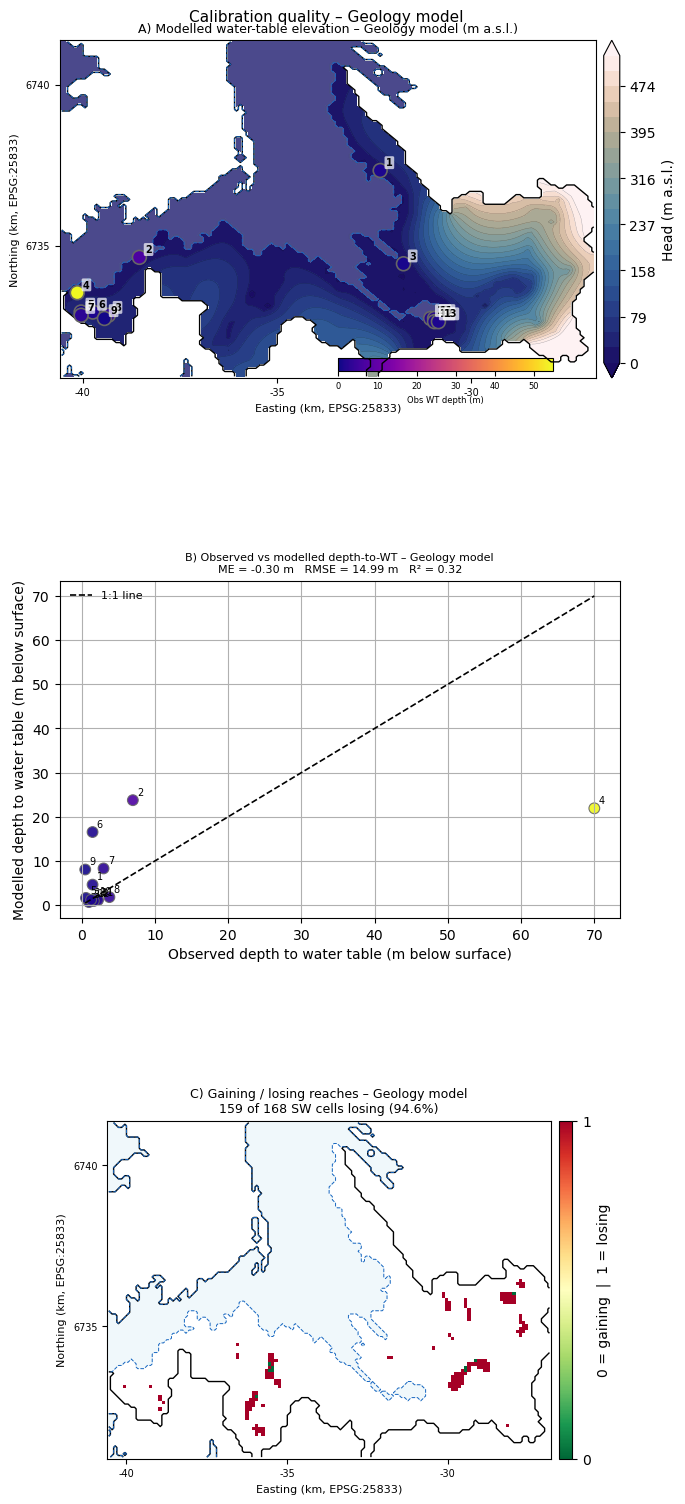


Modelled vs observed depth-to-water-table – Geology model:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,21330,1.50,4.65,3.15
1,2,55886,7.00,23.77,16.77
2,3,119296,1.00,0.70,-0.30
4,4,10004,70.00,21.93,-48.07
6,5,141713,0.60,1.65,1.05
7,6,141715,1.50,16.56,15.06
8,7,141714,3.00,8.32,5.32
9,8,141718,3.80,1.83,-1.97
10,9,141717,0.50,8.08,7.58
11,10,129754,2.00,1.43,-0.57


In [51]:

# Calibration quality: geology model
plot_calibration_comparison(
    head_geo, diag_geo, eval_geo,
    stats_geo, targets_geo, 'Geology model'
)

# Modelled vs observed depth-to-WT table
if not eval_geo.empty:
    print('\nModelled vs observed depth-to-water-table – Geology model:')
    tbl_g = eval_geo.copy()
    tbl_g['model_depth_m'] = tbl_g['dem_m'] - tbl_g['model_head_m']
    tbl_g['depth_resid_m'] = tbl_g['model_depth_m'] - tbl_g['obs_depth_m']
    tbl_g_disp = tbl_g[['well_no', 'station_id',
                          'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_g_disp.columns = ['Well #', 'Station ID',
                            'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_g_disp)


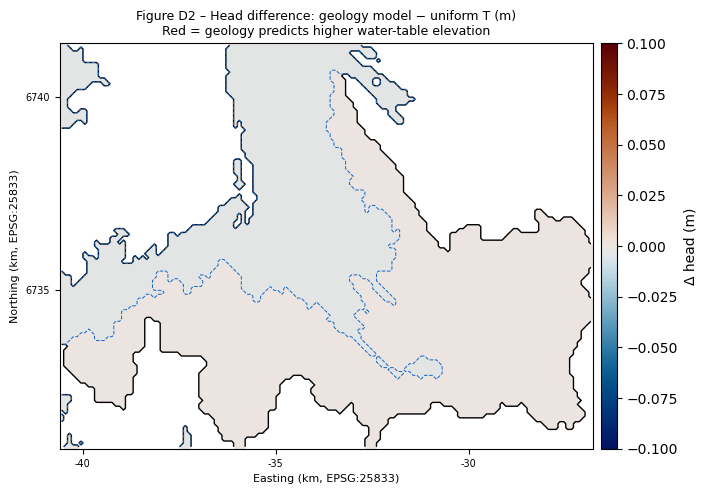

In [52]:

# Figure D2: Head difference (geology − uniform) — single-column map
drn_elev_g = diag_geo['drn_elev']
below_wt_g = sw_cells & np.isfinite(head_geo) & (head_geo < drn_elev_g)

ph = _panel_h()
fig, ax = plt.subplots(1, 1, figsize=(7, ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.10)

diff_map = np.where(active, head_geo - head_uniform, np.nan)
vlim = max(abs(np.nanpercentile(diff_map, 2)), abs(np.nanpercentile(diff_map, 98)))
im_diff = ax.imshow(diff_map, cmap=cmc.vik, vmin=-vlim, vmax=vlim)
ax.set_title(
    'Figure D2 – Head difference: geology model − uniform T (m)\n'
    'Red = geology predicts higher water-table elevation',
    fontsize=9)
_cbar(im_diff, ax, 'Δ head (m)')
add_map_ticks(ax)
add_map_overlays(ax)
plt.show()


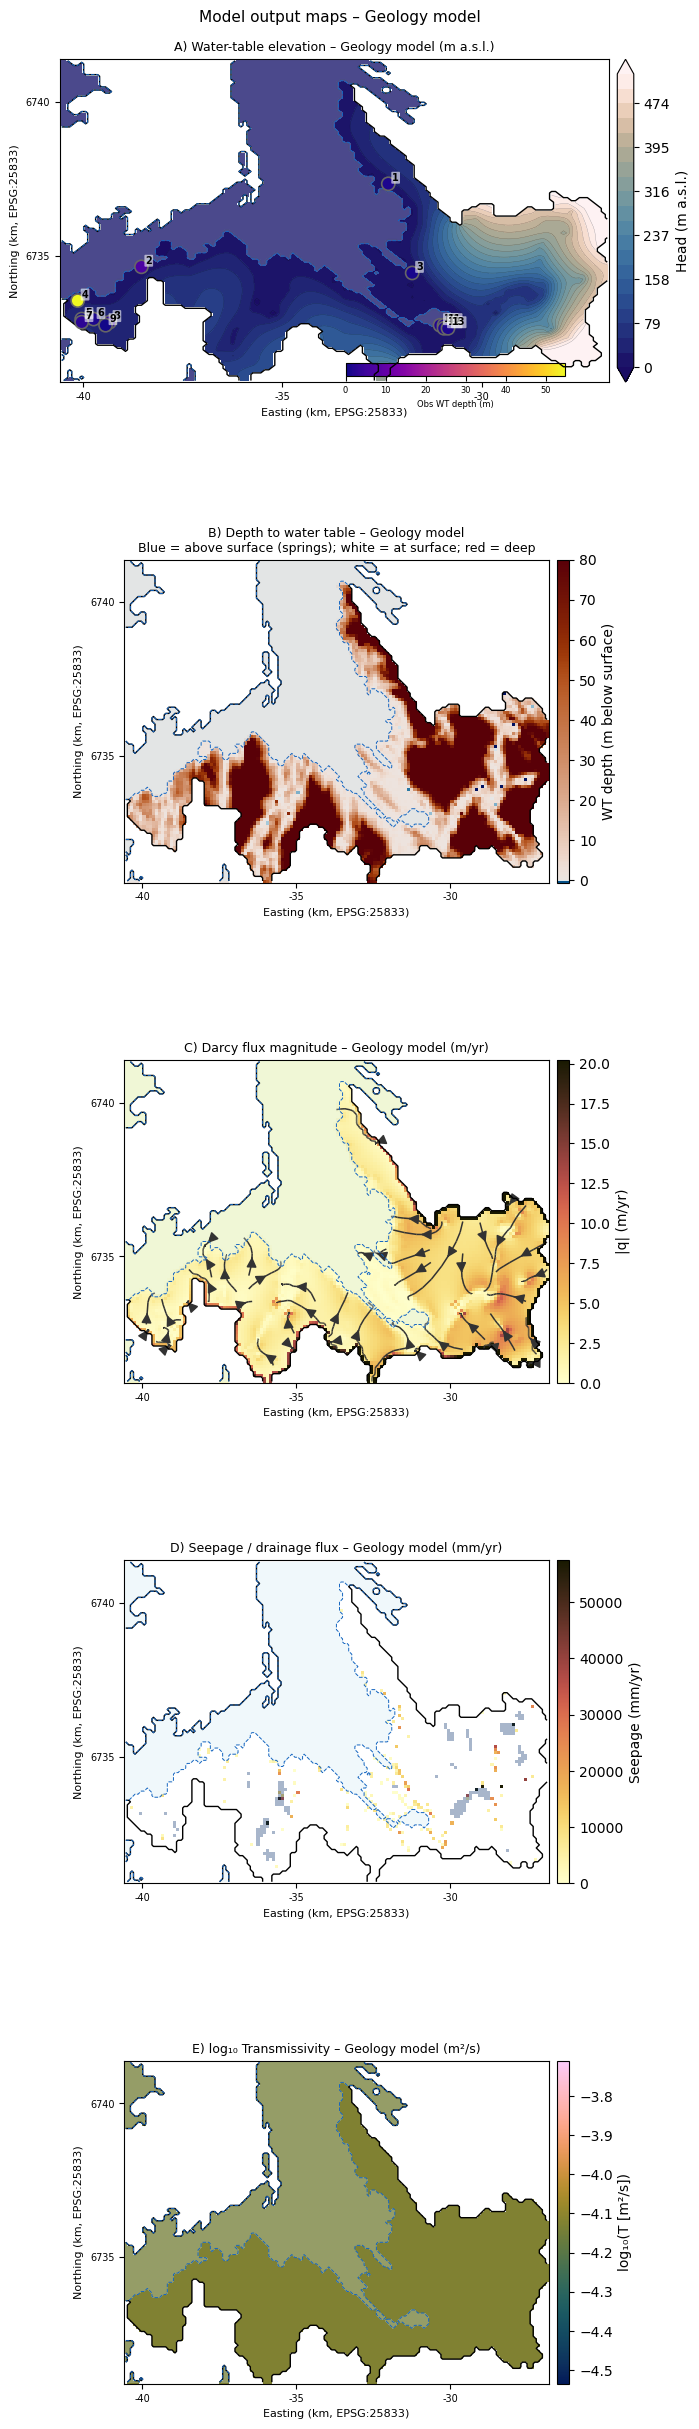

In [53]:

# Full model output maps for the geology calibration
plot_model_output(
    head_geo, diag_geo, best_hk_geo, 'Geology model',
    show_obs=eval_geo if not eval_geo.empty else None
)


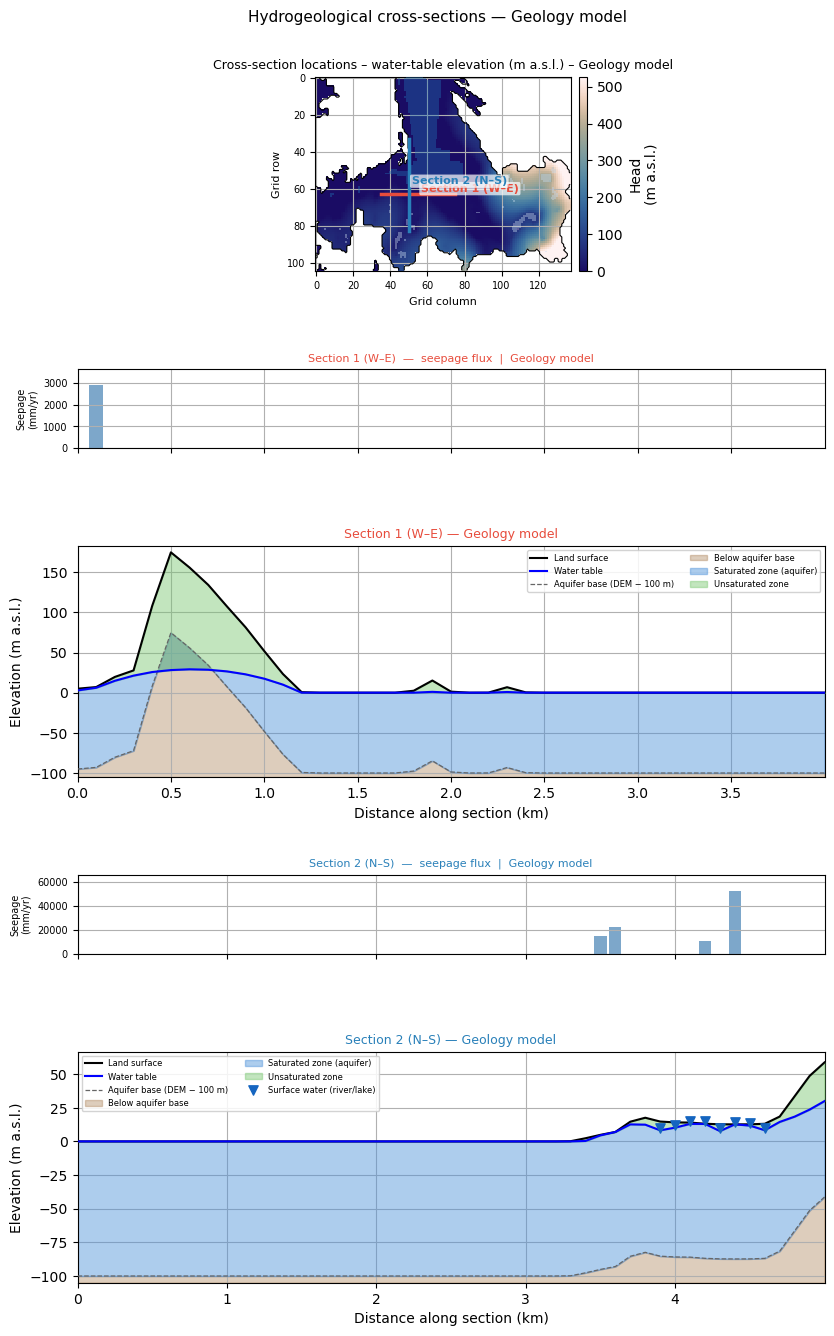

In [54]:

# Cross-sections along student-defined lines – Geology model
plot_cross_sections(head_geo, diag_geo, 'Geology model',
                    transects=user_transects if user_transects else None)



---
## Calibration Summary

Side-by-side comparison of all calibrations run so far.  Use this table when
writing your assignment answers.


In [55]:

def _fmt(d, key, fmt='.2f'):
    v = d.get(key, np.nan) if d else np.nan
    try:
        fv = float(v)
    except (TypeError, ValueError):
        return str(v)
    return f'{fv:{fmt}}' if np.isfinite(fv) else 'n/a'

rows = {
    'Metric': [
        'RMSE (m)', 'R²', 'Bias (m)',
        'Seepage match fraction',
        'SW stage RMSE (m)',
        'Losing-reach fraction',
        'Combined loss',
    ],
    'Uniform T': [
        _fmt(stats_uniform, 'rmse'), _fmt(stats_uniform, 'r2', '.3f'),
        _fmt(stats_uniform, 'bias'),
        _fmt(targets_uniform, 'seepage_match_fraction', '.3f'),
        _fmt(targets_uniform, 'surfacewater_stage_rmse_m'),
        _fmt(targets_uniform, 'below_wt_fraction', '.3f'),
        f"{uniform_result['loss']:.3f}",
    ],
    'Geology model': [
        _fmt(stats_geo, 'rmse'), _fmt(stats_geo, 'r2', '.3f'),
        _fmt(stats_geo, 'bias'),
        _fmt(targets_geo, 'seepage_match_fraction', '.3f'),
        _fmt(targets_geo, 'surfacewater_stage_rmse_m'),
        _fmt(targets_geo, 'below_wt_fraction', '.3f'),
        f"{geo_result['loss']:.3f}",
    ],
}

summary = pd.DataFrame(rows)
display(summary)


,Metric,Uniform T,Geology model
0,RMSE (m),14.99,14.99
1,R²,0.693,0.693
2,Bias (m),0.30,0.30
3,Seepage match fraction,0.054,0.054
4,SW stage RMSE (m),50.80,50.80
5,Losing-reach fraction,0.946,0.946
6,Combined loss,4.176,4.176



---
## Part F: Seepage and Drainage Flux Analysis

The drain boundary records how much water leaves the aquifer at each model cell.
Mapping these fluxes helps to:

- Locate where groundwater exfiltrates to the land surface.
- Check whether predicted discharge patterns match mapped rivers and lakes.
- Quantify each calibration scenario's spatial drainage pattern.

Fluxes are expressed in **mm/yr** for direct comparison with recharge.


In [56]:

# Seepage / drainage flux summary for all available calibrations.
seep_geo = gwu.seepage_flux_stats(
    diag_geo['drn_flux'], active, sw, sea, delr, delc)
seep_unif = gwu.seepage_flux_stats(
    diag_uniform['drn_flux'], active, sw, sea, delr, delc)

print('=== Seepage flux summary ===')
for label, seep_s in [('Uniform T', seep_unif), ('Geology model', seep_geo)]:
    print(f'\n{label}:')
    print(f"  Total discharge  : {seep_s['total_seepage_m3_s']:.3e} m³/s")
    print(f"  Domain-mean rate : {seep_s['total_seepage_mm_yr']:.1f} mm/yr")
    print(f"  At SW cells      : {seep_s['sw_seepage_m3_s']:.3e} m³/s")
    print(f"  At upland cells  : {seep_s['upland_seepage_m3_s']:.3e} m³/s")


=== Seepage flux summary ===

Uniform T:
  Total discharge  : 7.612e-01 m³/s
  Domain-mean rate : 500.9 mm/yr
  At SW cells      : 3.500e-01 m³/s
  At upland cells  : 4.112e-01 m³/s

Geology model:
  Total discharge  : 7.612e-01 m³/s
  Domain-mean rate : 500.9 mm/yr
  At SW cells      : 3.500e-01 m³/s
  At upland cells  : 4.112e-01 m³/s


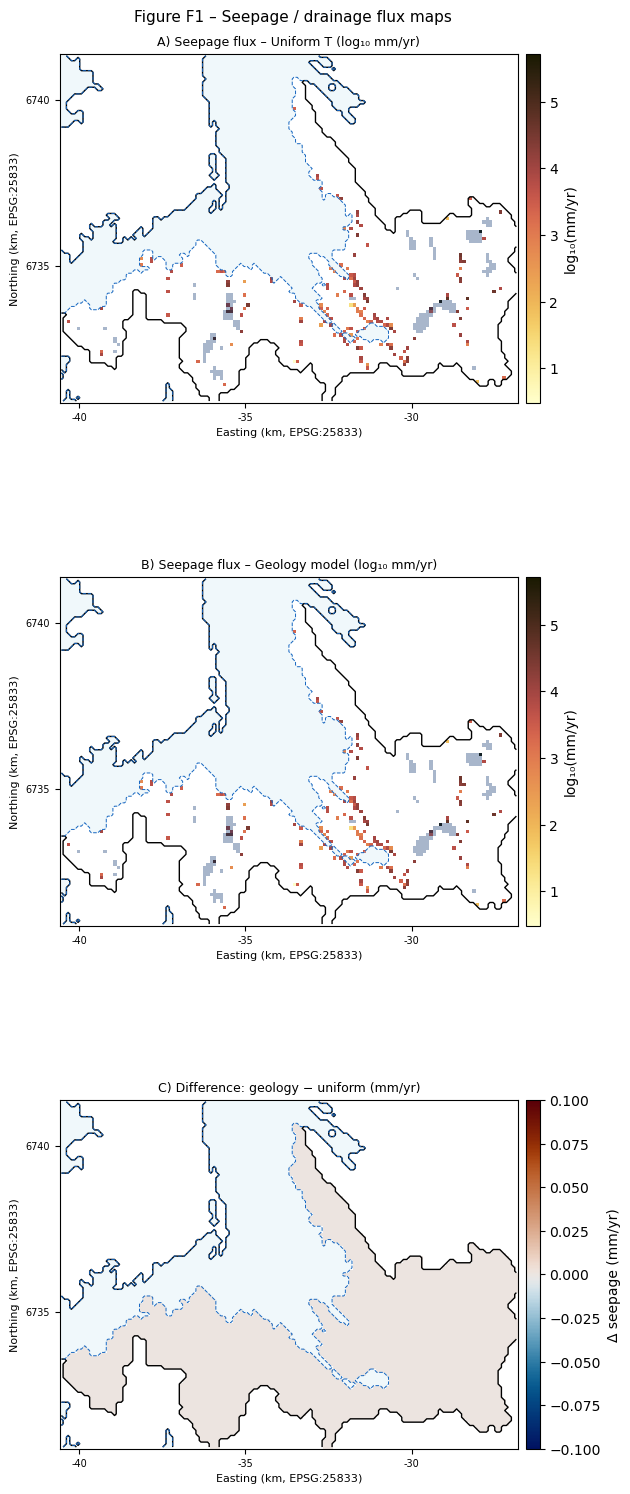

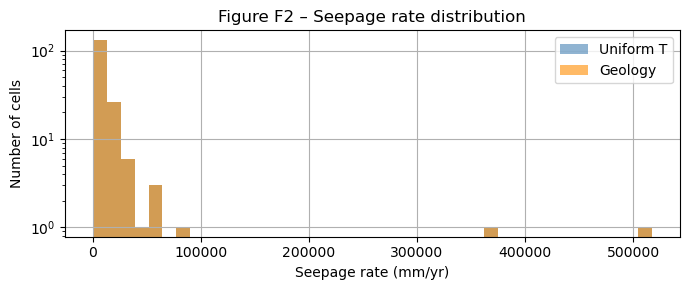

In [57]:

# Figure F1: Seepage flux maps (3 panels, single column)
seep_map_geo  = seep_geo['seepage_map_mm_yr']
seep_map_unif = seep_unif['seepage_map_mm_yr']
diff_seep = seep_map_geo - seep_map_unif

ph = _panel_h()
fig, axes = plt.subplots(3, 1, figsize=(7, 3 * ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.96, bottom=0.02, hspace=0.5)

panels = [
    (seep_map_unif, 'A) Seepage flux – Uniform T (log₁₀ mm/yr)', False),
    (seep_map_geo,  'B) Seepage flux – Geology model (log₁₀ mm/yr)', False),
    (diff_seep,     'C) Difference: geology − uniform (mm/yr)', True),
]

for ax, (smap, title, is_diff) in zip(axes, panels):
    if is_diff:
        d = np.where(active & ~is_sea, smap, np.nan)
        vmax_d = max(abs(np.nanpercentile(d, 5)), abs(np.nanpercentile(d, 95)))
        im = ax.imshow(d, cmap=cmc.vik, vmin=-vmax_d, vmax=vmax_d)
        _cbar(im, ax, 'Δ seepage (mm/yr)')
    else:
        seep_pos = np.where(active & ~is_sea & (smap > 0), smap, np.nan)
        im = ax.imshow(np.log10(np.maximum(seep_pos, 1e-3)), cmap=cmc.lajolla)
        _cbar(im, ax, 'log₁₀(mm/yr)')
        sw_ov = np.ma.masked_where(~sw_cells, np.ones(dem.shape))
        ax.imshow(sw_ov, cmap='Blues', alpha=0.35, vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    add_map_ticks(ax)
    add_map_overlays(ax)

fig.suptitle('Figure F1 – Seepage / drainage flux maps', fontsize=11, y=0.99)
plt.show()

# Figure F2: Seepage histogram (unchanged – no map)
fig2, ax2 = plt.subplots(figsize=(7, 3))
for label, smap, col in [
    ('Uniform T', seep_map_unif, 'steelblue'),
    ('Geology',   seep_map_geo,  'darkorange'),
]:
    vals = smap[active & ~is_sea & (smap > 0)]
    if vals.size > 0:
        ax2.hist(vals, bins=40, color=col, alpha=0.6, label=label, edgecolor='none')
ax2.set_xlabel('Seepage rate (mm/yr)')
ax2.set_ylabel('Number of cells')
ax2.set_title('Figure F2 – Seepage rate distribution')
ax2.set_yscale('log')
ax2.legend()
fig2.tight_layout()
plt.show()


---
## Part G: Catchment Water Budget

The groundwater system is in steady state, so total recharge must equal the sum
of all discharge pathways:

$$Recharge = Q_{SW} + Q_{seepage} + Q_{sea}}$$

Each component is normalised by the active land area to give **mm/yr**, which
can be compared directly with precipitation and evapotranspiration estimates.

| Component | Description |
|---|---|
| **Recharge** | Groundwater entering the system from the land surface |
| **SW discharge** | Groundwater discharging to mapped rivers and lakes |
| **Seepage** | Groundwater discharging to land outside SW cells |
| **Sea discharge** | Groundwater discharging to the sea (mass-balance residual) |


Component                        Uniform T     Geology
--------------------------------------------------------------
Recharge (IN)                        300.0         300.0
SW discharge (rivers/lakes)          230.3         230.3
Upland seepage (non-SW)              270.6         270.6
Sea discharge (residual)            -200.9        -200.9
Active land area: 48.0 km²


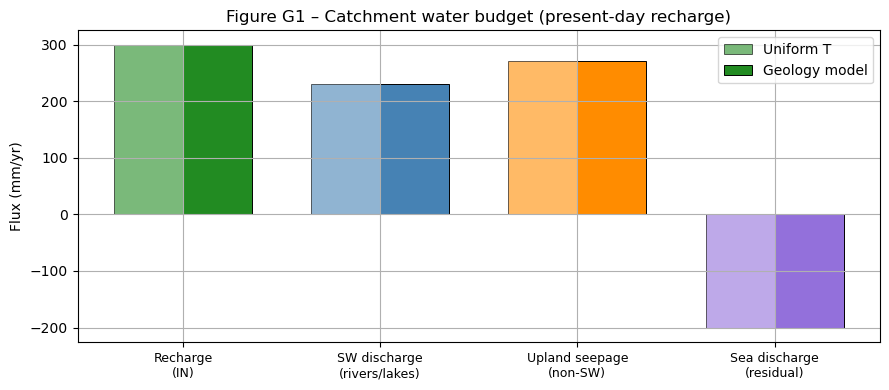

In [58]:
# ══ Part G: Catchment-wide water budget ═════════════════════════════════════════════════════
# gwu.water_budget() uses the steady-state mass balance:
#   Recharge (IN) = SW discharge + Upland seepage + Sea discharge (all OUT)
# Sea discharge is the residual because the CHD sea-boundary flux is not
# stored in diagnostics.

wb_unif = gwu.water_budget(
    diag_uniform['drn_flux'], rch, active, sw, sea, delr, delc)
wb_geo = gwu.water_budget(
    diag_geo['drn_flux'], rch, active, sw, sea, delr, delc)

# ── Print budget table ─────────────────────────────────────────────────────────────
print('=' * 62)
print(f"{'Component':<30s}  {'Uniform T':>10s}  {'Geology':>10s}")
print('-' * 62)
for _key, _label in [
    ('recharge_mm_yr',       'Recharge (IN)'),
    ('sw_discharge_mm_yr',   'SW discharge (rivers/lakes)'),
    ('upland_seepage_mm_yr', 'Upland seepage (non-SW)'),
    ('sea_discharge_mm_yr',  'Sea discharge (residual)'),
]:
    vu = wb_unif[_key]
    vg = wb_geo[_key]
    print(f'{_label:<30s}  {vu:>10.1f}    {vg:>10.1f}')
print('=' * 62)
print(f"Active land area: {wb_unif['land_area_m2'] / 1e6:.1f} km²")

# ── Bar chart ────────────────────────────────────────────────────────────────────
_budget_keys = [
    ('recharge_mm_yr',       'Recharge\n(IN)',              'forestgreen'),
    ('sw_discharge_mm_yr',   'SW discharge\n(rivers/lakes)', 'steelblue'),
    ('upland_seepage_mm_yr', 'Upland seepage\n(non-SW)',     'darkorange'),
    ('sea_discharge_mm_yr',  'Sea discharge\n(residual)',    'mediumpurple'),
]
_xlabels = [t[1] for t in _budget_keys]
_x = np.arange(len(_budget_keys))
_w = 0.35
_vals_u = [wb_unif[t[0]] for t in _budget_keys]
_vals_g = [wb_geo[t[0]] for t in _budget_keys]
_colors = [t[2] for t in _budget_keys]

fig_g, ax_g = plt.subplots(figsize=(9, 4))
ax_g.bar(_x - _w/2, _vals_u, _w, label='Uniform T',
         color=_colors, alpha=0.60, edgecolor='k', linewidth=0.7)
ax_g.bar(_x + _w/2, _vals_g, _w, label='Geology model',
         color=_colors, alpha=1.00, edgecolor='k', linewidth=0.7)
ax_g.set_ylabel('Flux (mm/yr)')
ax_g.set_title('Figure G1 – Catchment water budget (present-day recharge)')
ax_g.set_xticks(_x)
ax_g.set_xticklabels(_xlabels, fontsize=9)
ax_g.legend()
fig_g.tight_layout()
plt.show()



---
## Save Calibration Results for Exercise 5C

The best calibrated K field and all required grid arrays are saved to an `.npz`
file.  Exercise 5C loads this file to run flooding scenarios and pumping tests
without repeating the calibration.


In [59]:

# ── Save legacy .npz (used by Exercise 5C) ────────────────────────────────────
cal_output = data_dir / 'calibrated_hk.npz'
np.savez(
    cal_output,
    best_hk               = best_hk_for_events,
    dem                   = dem,
    sw                    = sw,
    sea                   = sea,
    active                = active,
    rch                   = rch,
    delr                  = np.array([delr]),
    delc                  = np.array([delc]),
    nrow                  = np.array([nrow]),
    ncol                  = np.array([ncol]),
    aquifer_thickness_m           = np.array([aquifer_thickness_m]),
    sea_level_m                   = np.array([sea_level_m]),
    default_drain_bed_k_m_s       = np.array([default_drain_bed_k_m_s]),
    default_drain_bed_thickness_m = np.array([default_drain_bed_thickness_m]),
    drain_coupling_depth_m        = np.array([drain_coupling_depth_m]),
)
print(f'Legacy .npz saved → {cal_output}')

# ── Save full model outputs as xarray / NetCDF ────────────────────────────────
# Cell-centre coordinates in the model grid (EPSG:25833 projected)
x_coords = np.array([transform.c + (j + 0.5) * delr for j in range(ncol)])
y_coords = np.array([transform.f - (i + 0.5) * delc for i in range(nrow)])  # descending (N→S)

# Derive seepage maps for both calibrations (already computed if seep_geo/seep_unif exist)
seep_map_geo_nc  = seep_geo['seepage_map_mm_yr'] if 'seep_geo' in dir() else np.full_like(dem, np.nan)
seep_map_unif_nc = seep_unif['seepage_map_mm_yr'] if 'seep_unif' in dir() else np.full_like(dem, np.nan)

ds = xr.Dataset(
    {
        'head_uniform': (
            ['y', 'x'],
            np.where(active, head_uniform, np.nan).astype(np.float32),
            {'long_name': 'Modelled water-table head – uniform T', 'units': 'm a.s.l.'}),
        'head_geology': (
            ['y', 'x'],
            np.where(active, head_geo, np.nan).astype(np.float32),
            {'long_name': 'Modelled water-table head – geology K', 'units': 'm a.s.l.'}),
        'best_hk': (
            ['y', 'x'],
            best_hk_for_events.astype(np.float32),
            {'long_name': 'Calibrated hydraulic conductivity', 'units': 'm/s'}),
        'dem': (
            ['y', 'x'],
            dem.astype(np.float32),
            {'long_name': 'Land-surface elevation', 'units': 'm a.s.l.'}),
        'active': (
            ['y', 'x'],
            active.astype(np.uint8),
            {'long_name': 'Active model domain (1 = active)'}),
        'sw': (
            ['y', 'x'],
            sw.astype(np.int16),
            {'long_name': 'Surface water type (0=none,1=lake,2=river,3=sea)'}),
        'sea': (
            ['y', 'x'],
            sea.astype(np.int16),
            {'long_name': 'Sea mask (1 = sea)'}),
        'geology': (
            ['y', 'x'],
            geo.astype(np.int16),
            {'long_name': 'Geology unit ID'}),
        'recharge_mm_yr': (
            ['y', 'x'],
            np.where(active, rch_mm_yr, np.nan).astype(np.float32),
            {'long_name': 'Effective recharge rate', 'units': 'mm/yr'}),
        'seepage_uniform_mm_yr': (
            ['y', 'x'],
            seep_map_unif_nc.astype(np.float32),
            {'long_name': 'Seepage/drainage flux – uniform T', 'units': 'mm/yr'}),
        'seepage_geology_mm_yr': (
            ['y', 'x'],
            seep_map_geo_nc.astype(np.float32),
            {'long_name': 'Seepage/drainage flux – geology K', 'units': 'mm/yr'}),
    },
    coords={
        'x': (['x'], x_coords, {'units': 'm', 'long_name': 'Easting EPSG:25833'}),
        'y': (['y'], y_coords, {'units': 'm', 'long_name': 'Northing EPSG:25833'}),
    },
    attrs={
        'title': 'Exercise 5A – calibrated steady-state groundwater model outputs',
        'crs': 'EPSG:25833',
        'cell_size_m': float(delr),
        'aquifer_thickness_m': float(aquifer_thickness_m),
        'sea_level_m': float(sea_level_m),
        'best_calibration': 'geology_K' if improved_geo else 'uniform_T',
    },
)

nc_path = data_dir / 'exercise5_model_outputs.nc'
ds.to_netcdf(nc_path)
print(f'xarray / NetCDF saved → {nc_path}')
print(ds)


Legacy .npz saved → data/model_input/calibrated_hk.npz
xarray / NetCDF saved → data/model_input/exercise5_model_outputs.nc
<xarray.Dataset>
Dimensions:                (y: 105, x: 138)
Coordinates:
  * x                      (x) float64 -4.054e+04 -4.044e+04 ... -2.684e+04
  * y                      (y) float64 6.741e+06 6.741e+06 ... 6.731e+06
Data variables:
    head_uniform           (y, x) float32 0.0 0.0 nan nan ... nan nan nan nan
    head_geology           (y, x) float32 0.0 0.0 nan nan ... nan nan nan nan
    best_hk                (y, x) float32 7.541e-07 7.541e-07 ... 1e-12 1e-12
    dem                    (y, x) float32 0.0 0.0 0.0 nan ... nan nan nan nan
    active                 (y, x) uint8 1 1 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    sw                     (y, x) int16 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    sea                    (y, x) int16 1 1 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    geology                (y, x) int16 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    re